# Tema 1 · Clasificación — Score de Riesgo Crediticio
## Demo del viernes (resuelto) · Dataset: **German Credit Data**

**Caso de negocio.** Una entidad financiera necesita clasificar a sus
solicitantes de crédito según su nivel de riesgo (**buen** vs. **mal** pagador)
para apoyar la decisión de otorgamiento. Construiremos un modelo que, a partir
de información financiera y demográfica del solicitante, prediga su categoría de
riesgo (`Risk`: *good* / *bad*).

En esta demo recorremos el **pipeline completo de clasificación** de principio a
fin, explicando la decisión detrás de cada paso:

1. Carga y exploración inicial
2. Análisis exploratorio (EDA)
3. Preprocesamiento (nulos, encoding, split, escalado)
4. Entrenamiento de 2 modelos (Regresión Logística y Random Forest)
5. Evaluación (matriz de confusión, reporte, ROC-AUC)
6. Interpretación (importancia de variables)
7. Conclusión de negocio


## 0. Semilla personal (anti-copia)

La primera celda define tu **cédula** como semilla. Alimenta el `random_state`
de los splits y modelos, y un muestreo del dataset, de modo que cada estudiante
obtenga resultados ligeramente distintos sobre la misma base.

> En la demo el instructor usa una cédula de ejemplo; cada estudiante pondrá la
> suya en su propia entrega.

In [1]:
cedula = 1020304050  # <-- reemplaza por tu número de cédula completo
import numpy as np
np.random.seed(cedula)
print(f"Semilla fijada en {cedula}")

Semilla fijada en 1020304050


## 1. Carga de datos y exploración inicial

Cargamos el CSV. La primera columna es un índice sin nombre, así que la usamos
como índice de fila (`index_col=0`).

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

df = pd.read_csv("../../data/01-clasificacion/german_credit_data.csv", index_col=0)
print("Dimensiones:", df.shape)
df.head()

Dimensiones: (1000, 10)


,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,49,male,1,own,little,NaN,2096,12,education,good
3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,53,male,2,free,little,little,4870,24,car,bad


**Muestreo con la semilla.** Tomamos el 85% de la base con `random_state=cedula`.
Así cada estudiante trabaja sobre un subconjunto ligeramente distinto.

In [3]:
df = df.sample(frac=0.85, random_state=cedula).reset_index(drop=True)
print("Dimensiones tras el muestreo:", df.shape)

Dimensiones tras el muestreo: (850, 10)


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 850 entries, 0 to 849
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Age               850 non-null    int64
 1   Sex               850 non-null    str  
 2   Job               850 non-null    int64
 3   Housing           850 non-null    str  
 4   Saving accounts   694 non-null    str  
 5   Checking account  514 non-null    str  
 6   Credit amount     850 non-null    int64
 7   Duration          850 non-null    int64
 8   Purpose           850 non-null    str  
 9   Risk              850 non-null    str  
dtypes: int64(4), str(6)
memory usage: 66.5 KB


In [5]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,850.0,NaN,NaN,NaN,35.585882,11.451656,19.0,27.0,33.0,42.0,75.0
Sex,850,2,male,586,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Job,850.0,NaN,NaN,NaN,1.912941,0.652582,0.0,2.0,2.0,2.0,3.0
Housing,850,3,own,599,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Saving accounts,694,4,little,508,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Checking account,514,3,moderate,235,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Credit amount,850.0,NaN,NaN,NaN,3245.843529,2806.217894,250.0,1360.25,2286.0,3965.75,18424.0
Duration,850.0,NaN,NaN,NaN,20.718824,11.983685,4.0,12.0,18.0,24.0,60.0
Purpose,850,8,car,288,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Risk,850,2,good,589,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Lectura rápida
- **10 variables:** demográficas (Age, Sex, Job, Housing) y financieras
  (Saving/Checking accounts, Credit amount, Duration, Purpose) + el target `Risk`.
- **Nulos** en *Saving accounts* y *Checking account* — los trataremos en el
  preprocesamiento.
- **Target categórico binario:** `good` / `bad`.

## 2. Análisis exploratorio (EDA)

### 2.1 Distribución del target
La primera pregunta en clasificación: **¿están balanceadas las clases?** Si no,
el *accuracy* solo puede engañar.

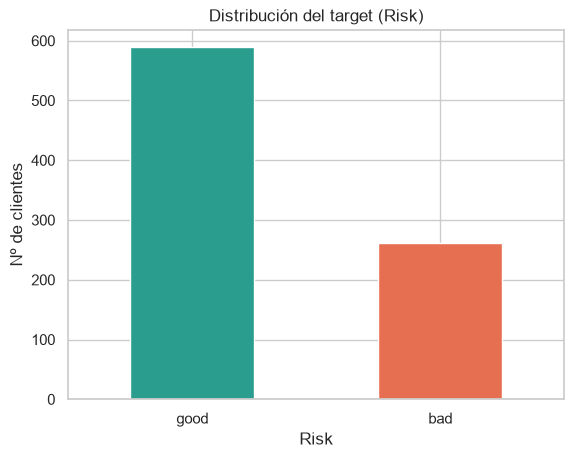

Risk
good    0.693
bad     0.307
Name: proportion, dtype: float64


In [6]:
ax = df["Risk"].value_counts().plot(kind="bar", color=["#2a9d8f", "#e76f51"])
ax.set_title("Distribución del target (Risk)")
ax.set_ylabel("Nº de clientes")
plt.xticks(rotation=0)
plt.show()

print(df["Risk"].value_counts(normalize=True).round(3))

Aproximadamente **70% good / 30% bad**: hay desbalance moderado. Lo tendremos
en cuenta al elegir métricas (F1, recall de la clase *bad*) y usaremos
`class_weight="balanced"` más adelante.

### 2.2 Variables numéricas vs. target

/var/folders/85/0szcbmmj5k95y52wkqp63pzc0000gr/T/ipykernel_32213/2821253871.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Risk", y=col, ax=ax, palette=["#2a9d8f", "#e76f51"])
/var/folders/85/0szcbmmj5k95y52wkqp63pzc0000gr/T/ipykernel_32213/2821253871.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Risk", y=col, ax=ax, palette=["#2a9d8f", "#e76f51"])
/var/folders/85/0szcbmmj5k95y52wkqp63pzc0000gr/T/ipykernel_32213/2821253871.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Risk", y=col, ax=ax, 

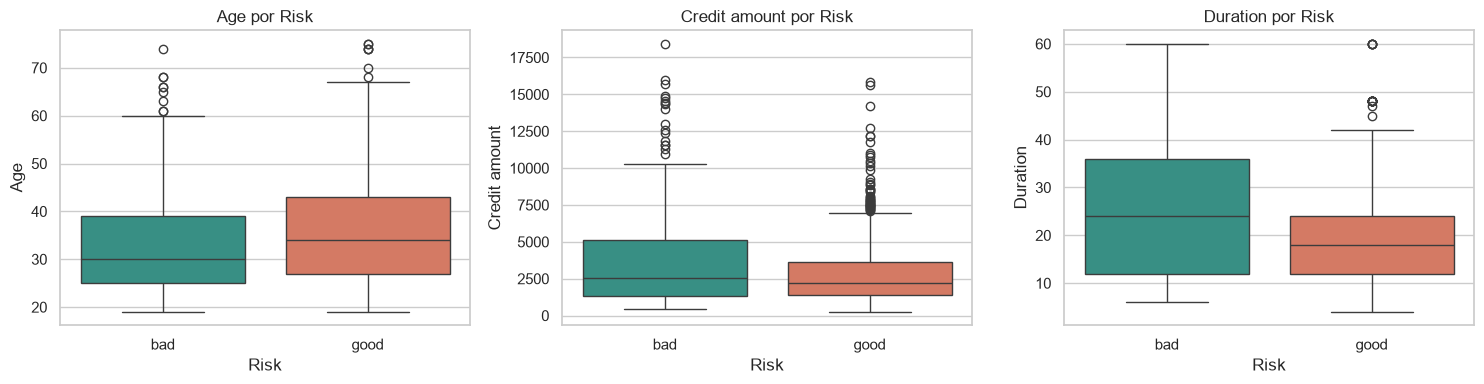

In [7]:
num_cols = ["Age", "Credit amount", "Duration"]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, num_cols):
    sns.boxplot(data=df, x="Risk", y=col, ax=ax, palette=["#2a9d8f", "#e76f51"])
    ax.set_title(f"{col} por Risk")
plt.tight_layout()
plt.show()

Se observa que los créditos **de mayor monto y mayor duración** tienden a
asociarse con más riesgo (*bad*). La edad discrimina menos.

### 2.3 Variables categóricas vs. target

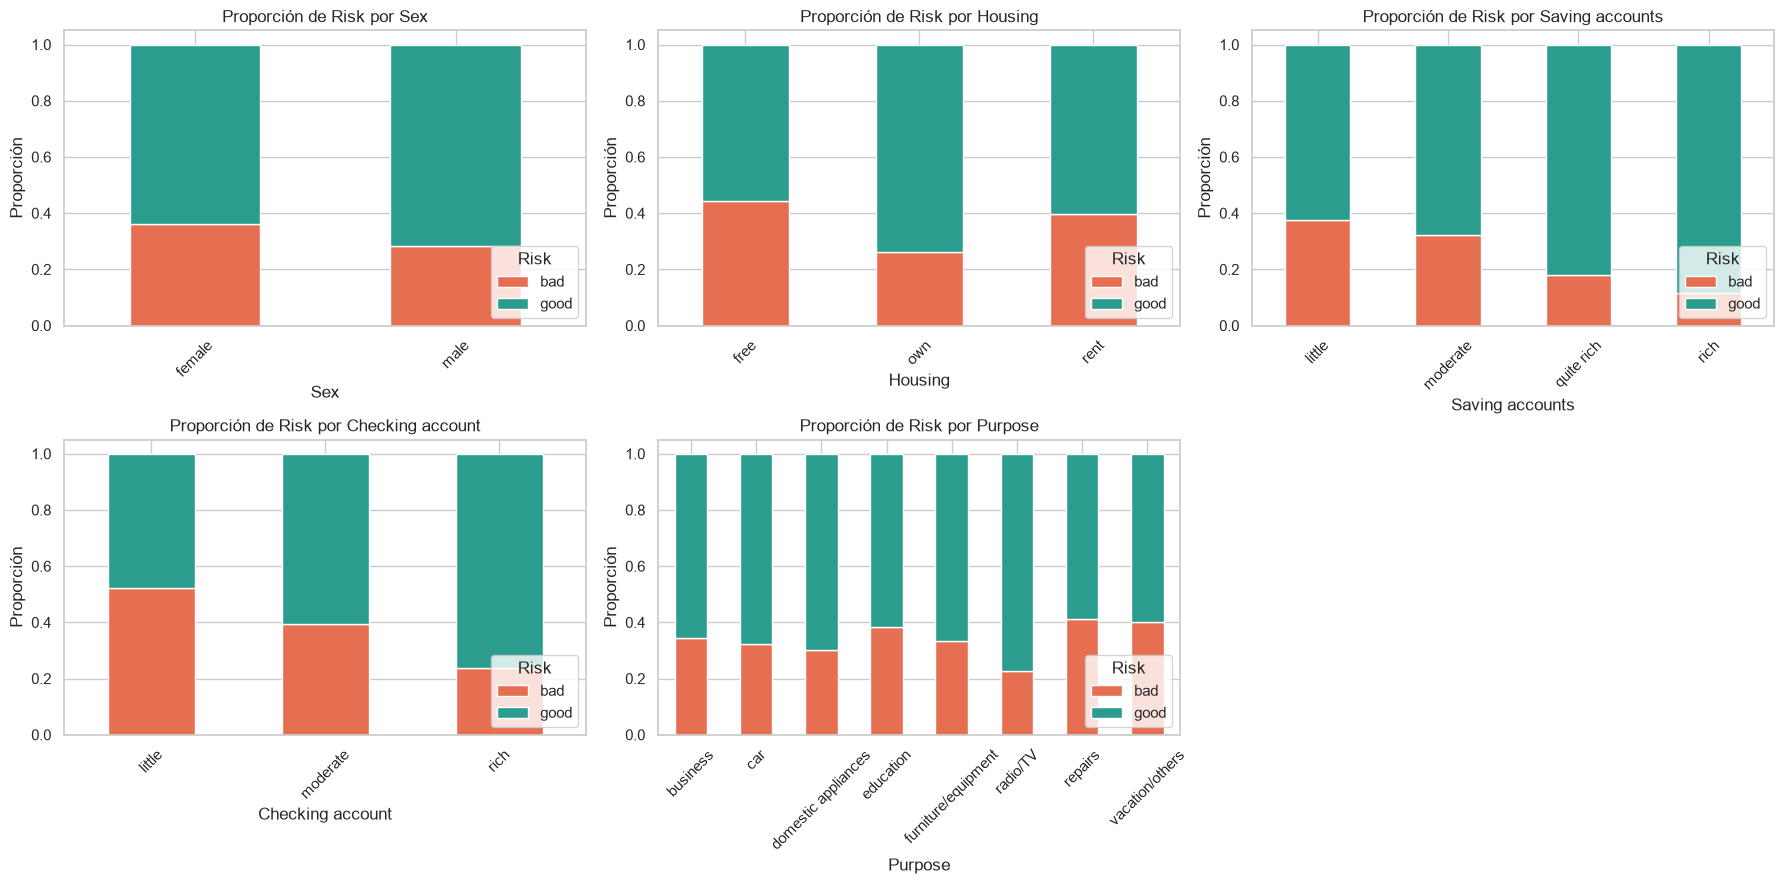

In [8]:
cat_cols = ["Sex", "Housing", "Saving accounts", "Checking account", "Purpose"]
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
for ax, col in zip(axes.ravel(), cat_cols):
    (df.groupby(col)["Risk"].value_counts(normalize=True)
       .unstack().plot(kind="bar", stacked=True, ax=ax,
                       color=["#e76f51", "#2a9d8f"]))
    ax.set_title(f"Proporción de Risk por {col}")
    ax.set_ylabel("Proporción")
    ax.legend(title="Risk", loc="lower right")
    ax.tick_params(axis="x", rotation=45)
axes.ravel()[-1].axis("off")
plt.tight_layout()
plt.show()

Por ejemplo, clientes con *little* en la cuenta corriente o de ahorros
tienden a concentrar más proporción de *bad*. Estas variables aportarán señal.

## 3. Preprocesamiento

### 3.1 Tratamiento de nulos
Los nulos en *Saving accounts* y *Checking account* **no son errores**: suelen
significar "sin cuenta / no informado". Los tratamos como una categoría propia
`"none"` en lugar de descartar filas.

In [9]:
df["Saving accounts"] = df["Saving accounts"].fillna("none")
df["Checking account"] = df["Checking account"].fillna("none")
print(df[["Saving accounts", "Checking account"]].isna().sum())

Saving accounts     0
Checking account    0
dtype: int64


### 3.2 Separar features (X) y target (y), y codificar el target

In [10]:
X = df.drop(columns=["Risk"])
y = (df["Risk"] == "bad").astype(int)   # 1 = mal pagador (clase de interés), 0 = buen pagador
print("Clase positiva = 'bad'. Distribución:")
print(y.value_counts())

Clase positiva = 'bad'. Distribución:
Risk
0    589
1    261
Name: count, dtype: int64


### 3.3 Encoding de categóricas + escalado de numéricas con un `ColumnTransformer`

Usamos un pipeline de scikit-learn: **One-Hot** para categóricas y
**StandardScaler** para numéricas. Encapsularlo evita fugas de datos entre
train y test.

In [11]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

categorical = ["Sex", "Housing", "Saving accounts", "Checking account", "Purpose", "Job"]
numeric = ["Age", "Credit amount", "Duration"]

preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical),
    ("num", StandardScaler(), numeric),
])
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

### 3.4 Train/test split
Estratificamos por `y` para conservar la proporción de clases, y usamos
`random_state=cedula`.

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=cedula
)
print("Train:", X_train.shape, "| Test:", X_test.shape)

Train: (637, 9) | Test: (213, 9)


## 4. Entrenamiento de modelos

Entrenamos dos modelos dentro de un `Pipeline` (preprocesamiento + modelo):
- **Regresión Logística** como *baseline* interpretable.
- **Random Forest** como modelo de ensamble más potente.

Ambos con `class_weight="balanced"` para compensar el desbalance.

In [13]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

logreg = Pipeline([
    ("prep", preprocessor),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced",
                               random_state=cedula)),
])
rf = Pipeline([
    ("prep", preprocessor),
    ("clf", RandomForestClassifier(n_estimators=300, class_weight="balanced",
                                   random_state=cedula)),
])

logreg.fit(X_train, y_train)
rf.fit(X_train, y_train)
print("Modelos entrenados.")

Modelos entrenados.


## 5. Evaluación

Comparamos ambos modelos con métricas apropiadas para clases desbalanceadas.

In [14]:
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, RocCurveDisplay)

for name, model in [("Regresión Logística", logreg), ("Random Forest", rf)]:
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    print(f"\n===== {name} =====")
    print(classification_report(y_test, y_pred, target_names=["good", "bad"]))
    print("ROC-AUC:", round(roc_auc_score(y_test, y_proba), 3))


===== Regresión Logística =====
              precision    recall  f1-score   support

        good       0.82      0.71      0.76       148
         bad       0.49      0.65      0.56        65

    accuracy                           0.69       213
   macro avg       0.66      0.68      0.66       213
weighted avg       0.72      0.69      0.70       213

ROC-AUC: 0.732

===== Random Forest =====
              precision    recall  f1-score   support

        good       0.81      0.79      0.80       148
         bad       0.54      0.57      0.56        65

    accuracy                           0.72       213
   macro avg       0.68      0.68      0.68       213
weighted avg       0.73      0.72      0.72       213

ROC-AUC: 0.752


### 5.1 Matriz de confusión (Random Forest)

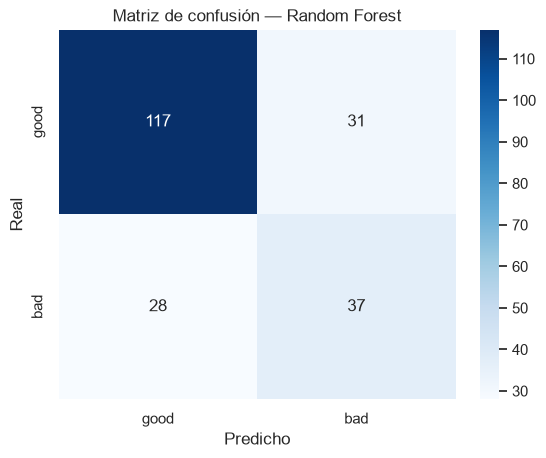

In [15]:
cm = confusion_matrix(y_test, rf.predict(X_test))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["good", "bad"], yticklabels=["good", "bad"])
plt.xlabel("Predicho"); plt.ylabel("Real")
plt.title("Matriz de confusión — Random Forest")
plt.show()

### 5.2 Curvas ROC comparadas

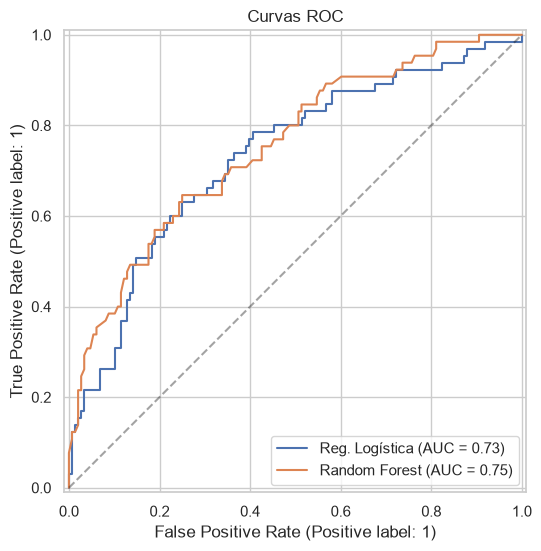

In [16]:
fig, ax = plt.subplots(figsize=(7, 6))
RocCurveDisplay.from_estimator(logreg, X_test, y_test, name="Reg. Logística", ax=ax)
RocCurveDisplay.from_estimator(rf, X_test, y_test, name="Random Forest", ax=ax)
ax.plot([0, 1], [0, 1], "k--", alpha=0.4)
ax.set_title("Curvas ROC")
plt.show()

## 6. Interpretación — ¿qué variables pesan más en el riesgo?

Extraemos la importancia de variables del Random Forest (tras el One-Hot).

/var/folders/85/0szcbmmj5k95y52wkqp63pzc0000gr/T/ipykernel_32213/679234645.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=imp.values, y=imp.index, palette="viridis")


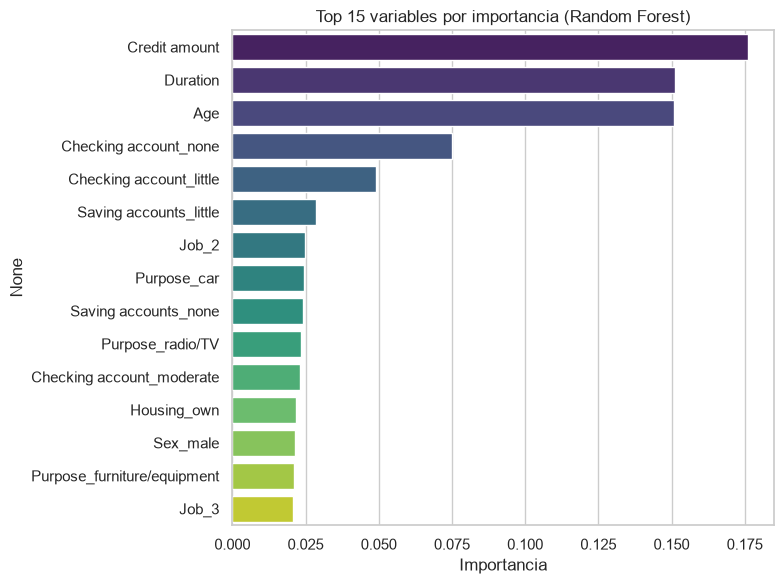

Credit amount                  0.176187
Duration                       0.151123
Age                            0.150711
Checking account_none          0.074951
Checking account_little        0.048905
Saving accounts_little         0.028409
Job_2                          0.024707
Purpose_car                    0.024491
Saving accounts_none           0.024209
Purpose_radio/TV               0.023520
Checking account_moderate      0.023210
Housing_own                    0.021882
Sex_male                       0.021429
Purpose_furniture/equipment    0.021163
Job_3                          0.020824
dtype: float64

In [17]:
import numpy as np
ohe = rf.named_steps["prep"].named_transformers_["cat"]
feat_names = list(ohe.get_feature_names_out(categorical)) + numeric
importances = rf.named_steps["clf"].feature_importances_

imp = (pd.Series(importances, index=feat_names)
         .sort_values(ascending=False).head(15))
plt.figure(figsize=(8, 6))
sns.barplot(x=imp.values, y=imp.index, palette="viridis")
plt.title("Top 15 variables por importancia (Random Forest)")
plt.xlabel("Importancia")
plt.tight_layout()
plt.show()
imp

## 7. Conclusión de negocio

- Las variables de **monto del crédito**, **duración** y el **estado de las
  cuentas corriente/ahorros** son las que más pesan en la predicción del riesgo,
  lo cual es coherente con el negocio: montos grandes a largo plazo y clientes
  con poca liquidez son más riesgosos.
- El **Random Forest** ofrece mejor ROC-AUC que la regresión logística, pero
  esta última es más interpretable (coeficientes). Para un comité de crédito que
  exige explicaciones, un modelo interpretable o técnicas como SHAP son valiosos.
- **Falsos negativos** (aprobar a alguien que no paga) son el error más costoso
  para el banco. Con `class_weight="balanced"` mejoramos el *recall* de la clase
  *bad*; se puede ajustar aún más bajando el umbral de decisión.

**Recomendación al área de crédito:** usar el modelo como apoyo (no reemplazo)
a la decisión, monitorear las variables de mayor peso, y priorizar reducir
falsos negativos ajustando el umbral según el apetito de riesgo.
